In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from tueplots import bundles
from tabulate import tabulate
from evaluation.metrics import get_p_values_from_table_data, get_weibull_survival
from evaluation.main_CRC_censoring import load_data, load_hyperparameters, train_and_validate_model
# from models.potential_outcomes import TEDVAE
from lifelines import KaplanMeierFitter

In [2]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})

In [3]:
n_bootstraps = 100
c_prop_nc = []
c_prop_ic = []
for i in range(n_bootstraps):
    cr_data = load_data(i=i, setting='no_censor')
    all_c = np.concatenate([cr_data['c_train'], cr_data['c_test'], cr_data['c_val']])
    c_prop_nc.append(np.mean(all_c))
    cr_data = load_data(i=i, setting='ic')
    all_c = np.concatenate([cr_data['c_train'], cr_data['c_test'], cr_data['c_val']])
    c_prop_ic.append(np.mean(all_c))

print(f'Mean of no-censor censoring: {np.mean(c_prop_nc)}')
print(f'Mean of ic-censoring: {np.mean(c_prop_ic)}')


Mean of no-censor censoring: 0.06131078224101482
Mean of ic-censoring: 0.3678646934460888


In [4]:
# Load the results from the stored files
save_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'evaluation', 'results_CRC_censoring')
results_path = os.path.join(save_path, 'results')
plots_path = os.path.join(save_path, 'plots')

with open(os.path.join(results_path, 'results.pkl'), 'rb') as f:
    results = pickle.load(f)

settings = [key for key in results.keys()]
models = [key for key in results[settings[0]].keys()]
n_bootstraps = len(results[settings[0]][models[0]]['ate_error_test'])

print(f"Loaded CRC results for {len(settings)} settings, {len(models)} models, and {n_bootstraps} datasets.")

Loaded CRC results for 2 settings, 7 models, and 100 datasets.


In [5]:
def get_pred_curves(input_dict, time_vector):  # Predicted survival curves using the Weibull distribution
    survival_train_0_outcome_pred = get_weibull_survival(concentration=input_dict['outcome_concentration_train'][0], scale=input_dict['outcome_scale_train'][0], time_vector=time_vector)
    survival_train_1_outcome_pred = get_weibull_survival(concentration=input_dict['outcome_concentration_train'][1], scale=input_dict['outcome_scale_train'][1], time_vector=time_vector)
    survival_test_0_outcome_pred = get_weibull_survival(concentration=input_dict['outcome_concentration_test'][0], scale=input_dict['outcome_scale_test'][0], time_vector=time_vector)
    survival_test_1_outcome_pred = get_weibull_survival(concentration=input_dict['outcome_concentration_test'][1], scale=input_dict['outcome_scale_test'][1], time_vector=time_vector)
    if 'censor_scale_train' in input_dict:
        survival_train_0_censor_pred = get_weibull_survival(concentration=input_dict['censor_concentration_train'][0], scale=input_dict['censor_scale_train'][0], time_vector=time_vector)
        survival_train_1_censor_pred = get_weibull_survival(concentration=input_dict['censor_concentration_train'][1], scale=input_dict['censor_scale_train'][1], time_vector=time_vector)
        survival_test_0_censor_pred = get_weibull_survival(concentration=input_dict['censor_concentration_test'][0], scale=input_dict['censor_scale_test'][0], time_vector=time_vector)
        survival_test_1_censor_pred = get_weibull_survival(concentration=input_dict['censor_concentration_test'][1], scale=input_dict['censor_scale_test'][1], time_vector=time_vector)
    else:
        survival_train_0_censor_pred, survival_train_1_censor_pred = None, None
        survival_test_0_censor_pred, survival_test_1_censor_pred = None, None

    return survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred

In [8]:
# Prepare a table to show some metrics
metrics = ['ate_predicted_test', 'ate_error_test', 'ci_td', 'ibs', 'd_calibration', 'rcll']
metric_names = ['ATE test', 'ATE_er_te', 'CI_td', 'IBS', 'DC', 'RCLL']
higher_is_better = [None, False, True, False, True, True]
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']

general_table = []

for setting in settings:
    table_data_mean = []
    table_data_std = []

    for model_name in models_to_show:
        tdm_mean = [setting, model_name]
        tdm_std = [setting, model_name]
        for m in metrics:
            if m in results[setting][model_name].keys():
                tdm_mean.append(f'{np.mean(results[setting][model_name][m]):.3f}')
                tdm_std.append(f'{np.std(results[setting][model_name][m]):.3f}')
            else:
                tdm_mean.append(np.nan)
                tdm_std.append(np.nan)
        table_data_mean.append(tdm_mean)
        table_data_std.append(tdm_std)

    # Add an * to the best value in each column
    for col in range(2, len(table_data_mean[0])):
        values = [float(row[col]) for row in table_data_mean]
        best_value = max(values) if higher_is_better[col - 2] else min(values)
        for irow, row in enumerate(table_data_mean):
            if float(row[col]) == best_value:
                row[col] += ' *'
            row[col] += 'pm' + str(table_data_std[irow][col])
    # Add everything to the general table
    general_table.extend(table_data_mean)
print("\nResults:")
print(tabulate(general_table, headers=['Setting', 'Model'] + [m for m in metric_names], tablefmt='latex'))


Results:
\begin{tabular}{llllllll}
\hline
 Setting   & Model        & ATE test         & ATE\_er\_te        & CI\_td          & IBS            & DC             & RCLL            \\
\hline
 no\_censor & s-learner    & 18.944 *pm17.904 & 19.451pm12.251   & 0.542pm0.030   & 0.137 *pm0.002 & 0.159 *pm0.231 & -6.187pm0.016   \\
 no\_censor & t-learner    & 32.063pm18.160   & 14.767pm10.649   & 0.536pm0.036   & 0.137 *pm0.002 & 0.034pm0.091   & -6.189pm0.017   \\
 no\_censor & tarnet       & 29.581pm20.575   & 17.077pm12.083   & 0.540pm0.038   & 0.137 *pm0.002 & 0.019pm0.052   & -6.191pm0.020   \\
 no\_censor & cfrnet       & 27.725pm16.550   & 12.980 *pm11.713 & 0.562 *pm0.042 & 0.137 *pm0.002 & 0.058pm0.142   & -6.186 *pm0.017 \\
 no\_censor & sa-tedvae-m0 & 30.501pm21.673   & 16.516pm14.323   & 0.558pm0.029   & 0.140pm0.003   & 0.087pm0.174   & -6.203pm0.027   \\
 no\_censor & sa-tedvae-m1 & 24.520pm25.685   & 17.687pm20.618   & 0.558pm0.032   & 0.140pm0.003   & 0.018pm0.050   & -6.199pm

In [9]:
# Statistical analysis of the results
metrics = ['ate_error_test', 'ci_td', 'ibs', 'd_calibration', 'rcll']
metric_names = ['ATE error', 'CI_td', 'IBS', 'DC', 'RCLL']
higher_is_better = [False, True, False, True, True]
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
name_map = {'s-learner': 'S-Learner',
            't-learner': 'T-Learner',
            'tarnet': 'TARNet',
            'cfrnet': 'CFRNet',
            'sa-tedvae-m0': 'SA-TEDVAE-NIC',
            'sa-tedvae-m1': 'SA-TEDVAE-CP',
            'sa-tedvae-m2': 'SA-TEDVAE-CT',
            'tmle': 'TMLE'}
data = np.zeros((len(models_to_show), len(metrics), len(settings) * n_bootstraps))
only_ate_metric = np.zeros((len(models_to_show), 1, len(settings) * n_bootstraps))
list_of_methods = []
for j, model_name in enumerate(models_to_show):
    list_of_methods.append(model_name)
    for i, setting in enumerate(settings):
        for k, m in enumerate(metrics):
            if m in results[setting][model_name].keys():
                data[j, k, i*n_bootstraps:(i+1)*n_bootstraps] = results[setting][model_name][m]
                if m == 'ate_error_test':
                    only_ate_metric[j, 0, i*n_bootstraps:(i+1)*n_bootstraps] = results[setting][model_name][m]
            else:
                if higher_is_better[k]:
                    data[j, k, i*n_bootstraps:(i+1)*n_bootstraps] = -np.inf
                else:
                    data[j, k, i*n_bootstraps:(i+1)*n_bootstraps] = np.inf

get_p_values_from_table_data(data, alpha=0.05, higher_is_better=higher_is_better, output_latex=False, list_of_methods=list_of_methods, list_of_metrics=metric_names, show_data=False)


Data for metric ATE error, where higher_is_better is False:
Friedman p-value: <1e-3, Davenport p-value: <1e-3 for metric ATE error
+---------------------------------------+-------------+-------------+----------+-------------------+----------------+----------------+----------------+
| Metric ATE error                      | s-learner   | t-learner   |   tarnet | cfrnet            | sa-tedvae-m0   |   sa-tedvae-m1 | sa-tedvae-m2   |
+=======================================+=============+=============+==========+===================+================+================+================+
| Average metric                        | 24.843      | 25.940      |   23.576 | 21.110            | 29.082         |         28.492 | 23.216         |
+---------------------------------------+-------------+-------------+----------+-------------------+----------------+----------------+----------------+
| Paired Wilcoxon tests (uncorrected)   | 0.002       | <1e-3       |    0.002 | 1.000* (baseline) | <1e-3  

In [11]:
with open(os.path.join(results_path, 'results_tmle.pkl'), 'rb') as f:
    results_tmle = pickle.load(f)
cols = ["Pt Est", "CI_lower", "CI_upper"]
df = results_tmle['ic'][models[0]]['pred_tmle'][0]
idx = df.index[df["Group"].eq(0)][1:]

tmle_ate_dict = {}
tmle_ate_error_dict = {}
for setting in settings:
    pred_tmle_a = results_tmle[setting]['s-learner']['pred_tmle']
    tmle_a_list = []
    for pred_df_tmle in pred_tmle_a:

        df = pred_df_tmle.copy()
        # Keep only needed columns
        df = df[["Time", "Group", "Pt Est"]].dropna()

        # Put Group 0 and Group 1 curves side by side
        wide = (
            df
            .pivot(index="Time", columns="Group", values="Pt Est")
            .sort_index()
        )

        # Rename for clarity
        F0 = wide[0].values   # cumulative incidence for control
        F1 = wide[1].values   # cumulative incidence for treated
        time = wide.index.values

        # If Pt Est is cumulative incidence:
        # S1(t) - S0(t) = [1 - F1(t)] - [1 - F0(t)] = F0(t) - F1(t)
        survival_diff = F0 - F1

        # Area between curves, using only the available time points
        ate_tmle = np.trapezoid(survival_diff, time)
        tmle_a_list.append(ate_tmle)

    # ate_real_a = [np.mean(results_tmle[setting]['s-learner']['ite_real_test'][i]) for i in range(10)]
    ate_real_a = results_tmle[setting][models[0]]['ate_gt']
    ate_error_a = [abs(ate_tmle_a_i - ate_real_a_i) for (ate_tmle_a_i, ate_real_a_i) in zip(tmle_a_list, ate_real_a)]

    print(f'predicted ate: {np.mean(tmle_a_list)} +- {np.std(tmle_a_list)}')
    ate_mae = np.mean(ate_error_a)
    ate_std = np.std(ate_error_a)
    print(f'{setting} ERROR: {ate_mae} +- {ate_std}')

    tmle_ate_dict[setting] = tmle_a_list
    tmle_ate_error_dict[setting] = ate_error_a

predicted ate: 16.027125304208347 +- 5.471114067447485
no_censor ERROR: 17.335363521109024 +- 5.471114067447485
predicted ate: 63.01399838166894 +- 26.667558752075475
ic ERROR: 33.204274161988636 +- 22.087256193137712


In [12]:
# include tmle metrics of ate in the data to make the p-values again
tmle_error_numpy = np.concatenate([tmle_ate_err for tmle_ate_err in tmle_ate_error_dict.values()])[:,None].T
only_ate_metric_2 = np.concatenate([only_ate_metric,tmle_error_numpy[None,...]] )
list_of_methods_2 =  list_of_methods + ['TMLE']
get_p_values_from_table_data(only_ate_metric_2, alpha=0.05, higher_is_better=[False], output_latex=False, list_of_methods=list_of_methods_2, list_of_metrics=['ATE error'], show_data=False)


Data for metric ATE error, where higher_is_better is False:
Friedman p-value: <1e-3, Davenport p-value: <1e-3 for metric ATE error
+---------------------------------------+-------------+-------------+----------+-------------------+----------------+----------------+----------------+--------+
| Metric ATE error                      | s-learner   | t-learner   |   tarnet | cfrnet            | sa-tedvae-m0   |   sa-tedvae-m1 | sa-tedvae-m2   | TMLE   |
+=======================================+=============+=============+==========+===================+================+================+================+========+
| Average metric                        | 24.843      | 25.940      |   23.576 | 21.110            | 29.082         |         28.492 | 23.216         | 25.270 |
+---------------------------------------+-------------+-------------+----------+-------------------+----------------+----------------+----------------+--------+
| Paired Wilcoxon tests (uncorrected)   | 0.002       | <1e-3  

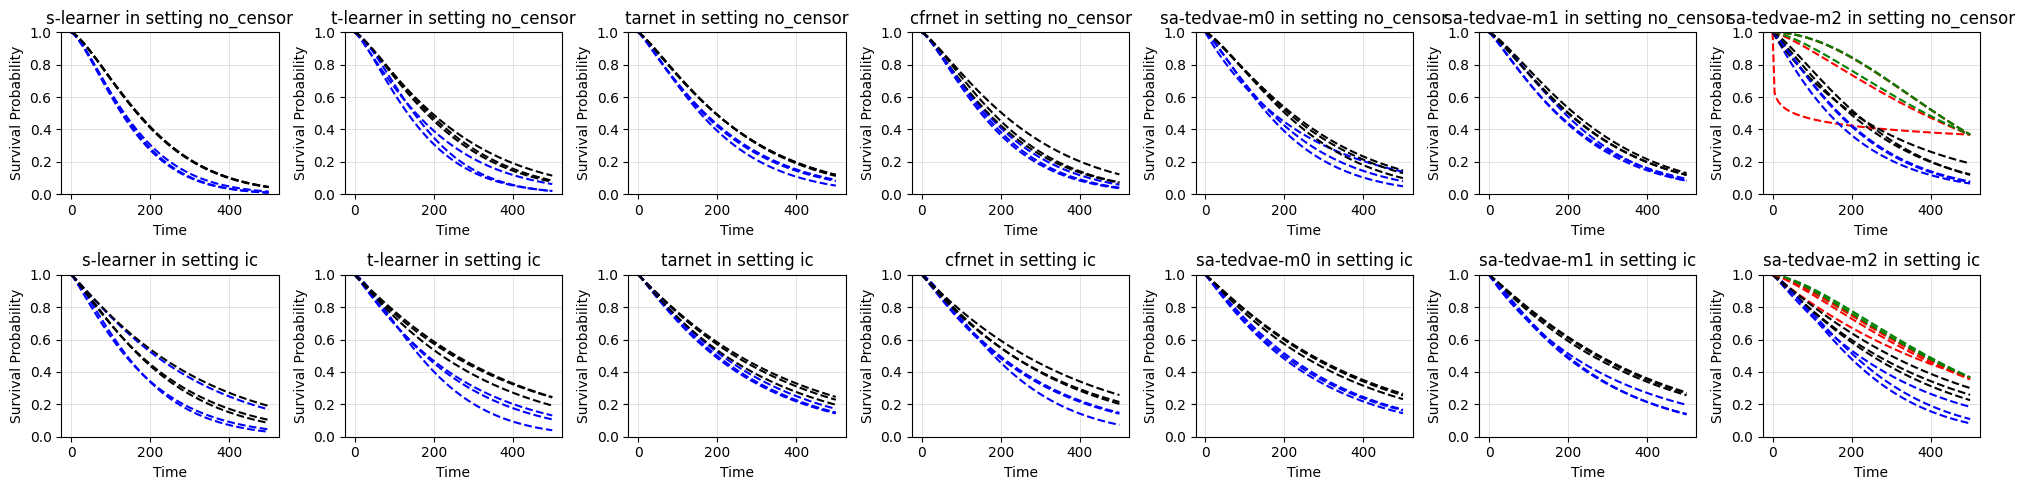

In [13]:
# Plot some curves for each setting...
n_datasets_to_plot = 3
patient_index = 0  # Change this to plot different patients
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
plt.subplots(len(settings), len(models_to_show), figsize=(20, 5))
model_index_plot = 1
time_vector = np.linspace(0, 500, 100)  # Vector to plot the time
for setting in settings:
    for model_name in models_to_show:
        plt.subplot(len(settings), len(models_to_show), model_index_plot)

        for i in range(n_datasets_to_plot):

            data_dict = {'outcome_scale_train': [o for o in results[setting][model_name]['outcome_scale_train'][i]],
                     'outcome_scale_test': [o for o in results[setting][model_name]['outcome_scale_test'][i]],
                     'outcome_concentration_train': [o for o in results[setting][model_name]['outcome_concentration_train'][i]],
                     'outcome_concentration_test': [o for o in results[setting][model_name]['outcome_concentration_test'][i]]}
            if model_name == 'sa-tedvae-m2':
                data_dict['censor_scale_train'] = [o for o in results[setting][model_name]['censor_scale_train'][i]]
                data_dict['censor_scale_test'] = [o for o in results[setting][model_name]['censor_scale_test'][i]]
                data_dict['censor_concentration_train'] = [o for o in results[setting][model_name]['censor_concentration_train'][i]]
                data_dict['censor_concentration_test'] = [o for o in results[setting][model_name]['censor_concentration_test'][i]]
            survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred = get_pred_curves(data_dict, time_vector)

            plt.plot(time_vector, survival_test_0_outcome_pred[:, patient_index].T, label=f"Pred 0", color='blue', linestyle='--')
            plt.plot(time_vector, survival_test_1_outcome_pred[:, patient_index].T, label=f"Pred 1", color='black', linestyle='--')
            if model_name == 'sa-tedvae-m2':  # We also have the censoring in this model
                plt.plot(time_vector, survival_test_0_censor_pred[:, patient_index].T, label=f"Pred 0 c", color='red', linestyle='--')
                plt.plot(time_vector, survival_test_1_censor_pred[:, patient_index].T, label=f"Pred 1 c", color='green', linestyle='--')
        plt.title(f"{model_name} in setting {setting}")
        plt.xlabel("Time")
        plt.ylabel("Survival Probability")
        plt.ylim([0, 1])
        plt.grid(True)
        model_index_plot += 1
plt.tight_layout()
plt.show()


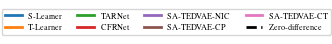

C:\Users\Alex\AppData\Local\Temp\ipykernel_12360\503891584.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


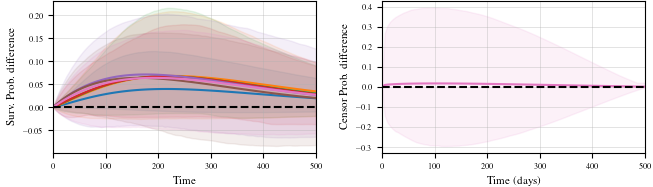

C:\Users\Alex\AppData\Local\Temp\ipykernel_12360\503891584.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


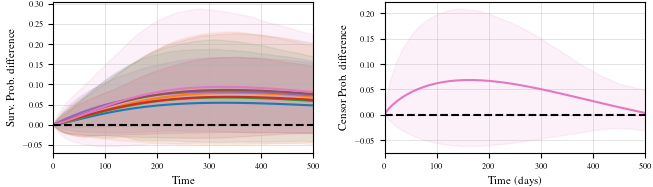

In [14]:
# Plot in detail the population estimation to compare across models
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
max_t = 500
time_vector = np.linspace(0, max_t, 100)  # Vector to plot the time

color_map = plt.get_cmap('tab10')

plot_colors = {
    model_name: color_map(i)
    for i, model_name in enumerate(models_to_show)
}
from matplotlib.lines import Line2D

plot_colors["Zero-diff."] = "k"

def aux_plot(list_of_arrays, label, color, percentile=2.5):
    list_of_arrays = np.array(list_of_arrays)
    mean_val, std_val = np.mean(list_of_arrays, axis=(0, 1)), np.std(list_of_arrays, axis=(0, 1))
    low_val, high_val = np.percentile(list_of_arrays, percentile, axis=(0, 1)), np.percentile(list_of_arrays, 100 - percentile, axis=(0, 1))
    plt.fill_between(time_vector, low_val, high_val, color=color, alpha=0.1)
    plt.plot(time_vector, mean_val, label=label, color=color)

def plot_and_save_shared_legend(save_path):
    legend_handles = [
        Line2D(
            [0], [0],
            color=plot_colors[model_name],
            lw=2,
            label=name_map[model_name]
        )
        for model_name in models_to_show
    ]

    legend_handles.append(
        Line2D(
            [0], [0],
            color=plot_colors["Zero-diff."],
            lw=2,
            label="Zero-difference",
            linestyle="--"
        )
    )

    # Same width as the main plots, but shorter height because this is only a legend
    main_width = plt.rcParams["figure.figsize"][0]
    fig_legend = plt.figure(
        figsize=(main_width/2, 0.5)
    )

    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis("off")

    ax_legend.legend(
        handles=legend_handles,
        loc="center",
        ncol=4,                 # 8 entries -> 2 rows
        mode="expand",          # occupy the full width
        frameon=True,
        bbox_to_anchor=(0, 0, 1, 1),
        borderaxespad=0,
        handlelength=2.0,
        columnspacing=1.0,
    )

    fig_legend.savefig(save_path, dpi=300, facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close(fig_legend)


# Plot and save the shared legend before the first main plot
with plt.rc_context({**bundles.icml2024(column='full', nrows=1, ncols=1, usetex=True)}):
    plot_and_save_shared_legend(
        os.path.join(plots_path, 'crc_diff_legend.pdf')
    )

for setting in settings:
    with plt.rc_context({**bundles.icml2024(column='full', nrows=1, ncols=2, usetex=True)}):

        plt.subplots(1, 2)

        color_index = 0
        color_map = plt.get_cmap('tab10')

        curves = {model_name: {} for model_name in models_to_show}

        for model_name in models_to_show:

            curves[model_name] = {'survival_test_outcome_diff': [], 'survival_test_censor_diff': []}

            for i in range(n_bootstraps):
                data_dict = {'outcome_scale_train': [o for o in results[setting][model_name]['outcome_scale_train'][i]],
                             'outcome_scale_test': [o for o in results[setting][model_name]['outcome_scale_test'][i]],
                             'outcome_concentration_train': [o for o in results[setting][model_name]['outcome_concentration_train'][i]],
                             'outcome_concentration_test': [o for o in results[setting][model_name]['outcome_concentration_test'][i]]}
                if model_name == 'sa-tedvae-m2':
                    data_dict['censor_scale_train'] = [o for o in results[setting][model_name]['censor_scale_train'][i]]
                    data_dict['censor_scale_test'] = [o for o in results[setting][model_name]['censor_scale_test'][i]]
                    data_dict['censor_concentration_train'] = [o for o in results[setting][model_name]['censor_concentration_train'][i]]
                    data_dict['censor_concentration_test'] = [o for o in results[setting][model_name]['censor_concentration_test'][i]]
                if model_name == 'sa-tedvae-m1':
                    data_dict['survival_test_censor_prop'] = [o for o in results[setting][model_name]['censor_prop_test_model'][i]]
                survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred = get_pred_curves(data_dict, time_vector)

                curves[model_name]['survival_test_outcome_diff'].append(survival_test_1_outcome_pred.T - survival_test_0_outcome_pred.T)

                if model_name == 'sa-tedvae-m2':
                    curves[model_name]['survival_test_censor_diff'].append(survival_test_1_censor_pred.T - survival_test_0_censor_pred.T)

        plt.subplot(1, 2, 1)

        for model_name in models_to_show:
            aux_plot(curves[model_name]['survival_test_outcome_diff'], label=name_map[model_name], color=color_map(color_index))
            color_index += 1
        plt.plot(time_vector, np.zeros_like(time_vector), color='k', label='Zero diff', linestyle='--')
        # plt.title(f"Treatment effect survival diff estimated " + setting)
        plt.xlabel("Time")
        plt.ylabel("Surv. Prob. difference")
        plt.xlim([0, max_t])
        plt.grid(True)
        # plt.legend(loc='best')

        plt.subplot(1, 2, 2)
        aux_plot(curves['sa-tedvae-m2']['survival_test_censor_diff'], label=f"Censor diff SA-TEDVAE-M2", color=plot_colors['sa-tedvae-m2'])

        plt.plot(time_vector, np.zeros_like(time_vector), color='k', label='Zero diff', linestyle='--')
        # plt.title(f"Treatment effect survival diff estimated " + setting)
        plt.xlabel("Time (days)")
        plt.ylabel("Censor Prob. difference")
        plt.xlim([0, max_t])
        plt.grid(True)
        # plt.legend(loc='best')
        plt.tight_layout()
        plt.rcParams.update(bundles.icml2024(usetex=False))
        plt.savefig(os.path.join(plots_path, f'crc_diff_{setting}.pdf'), dpi=300)
        plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_12360\2101353151.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


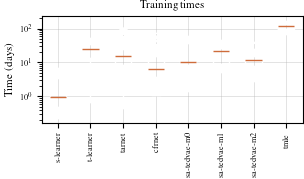

In [15]:
# Plot the training time for each model
# Load the training time data
with open(os.path.join(results_path, 'training_times.pkl'), 'rb') as f:
    training_times = pickle.load(f)

models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']

tmle_times = []
for setting in settings:
    for model_name in models_to_show:
        for e in results[setting][model_name]['t_tmle']:
            if e is not None:
                tmle_times.append(e)

if len(tmle_times) > 0:
    training_times['tmle'] = tmle_times
    models_to_show.append('tmle')

with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):

    plt.boxplot([np.array(training_times[model_name]) for model_name in models_to_show], tick_labels=models_to_show)
    plt.ylabel('Time (days)')
    plt.yscale('log')
    plt.title('Training times')
    plt.grid(True)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.rcParams.update(bundles.icml2024(usetex=False))
    plt.savefig(os.path.join(plots_path, f'crc_times.pdf'), dpi=300)
    plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_12360\2541816511.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


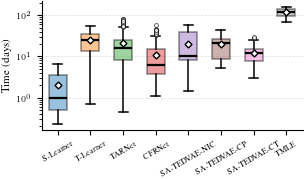

In [16]:
# Plot the training time for each model

# Load the training time data
with open(os.path.join(results_path, 'training_times.pkl'), 'rb') as f:
    training_times = pickle.load(f)

models_to_show = [
    's-learner',
    't-learner',
    'tarnet',
    'cfrnet',
    'sa-tedvae-m0',
    'sa-tedvae-m1',
    'sa-tedvae-m2'
]

tmle_times = []
for setting in settings:
    for model_name in models_to_show:
        for e in results[setting][model_name]['t_tmle']:
            if e is not None:
                tmle_times.append(e)

if len(tmle_times) > 0:
    training_times['tmle'] = tmle_times
    models_to_show.append('tmle')


with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):
    fig, ax = plt.subplots()

    data = []
    labels = []

    for model_name in models_to_show:
        values = np.asarray(training_times[model_name], dtype=float)

        # Log scale cannot display zero or negative values
        values = values[values > 0]

        data.append(values)
        labels.append(name_map.get(model_name, model_name.upper()))

    color_map = plt.get_cmap("tab10")
    colors = [
        color_map(i % 10)
        for i in range(len(models_to_show))
    ]

    box = ax.boxplot(
        data,
        patch_artist=True,
        tick_labels=labels,
        widths=0.55,
        showmeans=True,
        boxprops=dict(
            linewidth=1.1,
            color="black"
        ),
        whiskerprops=dict(
            linewidth=1.1,
            color="black"
        ),
        capprops=dict(
            linewidth=1.1,
            color="black"
        ),
        medianprops=dict(
            linewidth=1.6,
            color="black"
        ),
        meanprops=dict(
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3.5
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=2.8,
            alpha=0.7,
            linestyle="none"
        )
    )

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    ax.set_ylabel("Time (days)")
    ax.set_yscale("log")

    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    ax.tick_params(axis="x", rotation=30)

    # Cleaner frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        os.path.join(plots_path, "crc_times.pdf"),
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )

    plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_12360\204098776.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


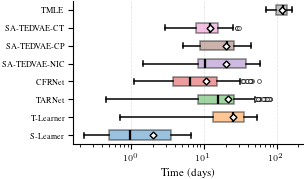

In [17]:
with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):
    fig, ax = plt.subplots()

    data = []
    labels = []

    for model_name in models_to_show:
        values = np.asarray(training_times[model_name], dtype=float)
        values = values[values > 0]

        data.append(values)
        labels.append(name_map.get(model_name, model_name.upper()))

    color_map = plt.get_cmap("tab10")
    colors = [
        color_map(i % 10)
        for i in range(len(models_to_show))
    ]

    box = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        tick_labels=labels,
        widths=0.55,
        showmeans=True,
        boxprops=dict(linewidth=1.1, color="black"),
        whiskerprops=dict(linewidth=1.1, color="black"),
        capprops=dict(linewidth=1.1, color="black"),
        medianprops=dict(linewidth=1.6, color="black"),
        meanprops=dict(
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3.5
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=2.8,
            alpha=0.7,
            linestyle="none"
        )
    )

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)

    ax.set_xlabel("Time (days)")
    ax.set_xscale("log")

    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        os.path.join(plots_path, "crc_times_horizontal.pdf"),
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )

    plt.show()

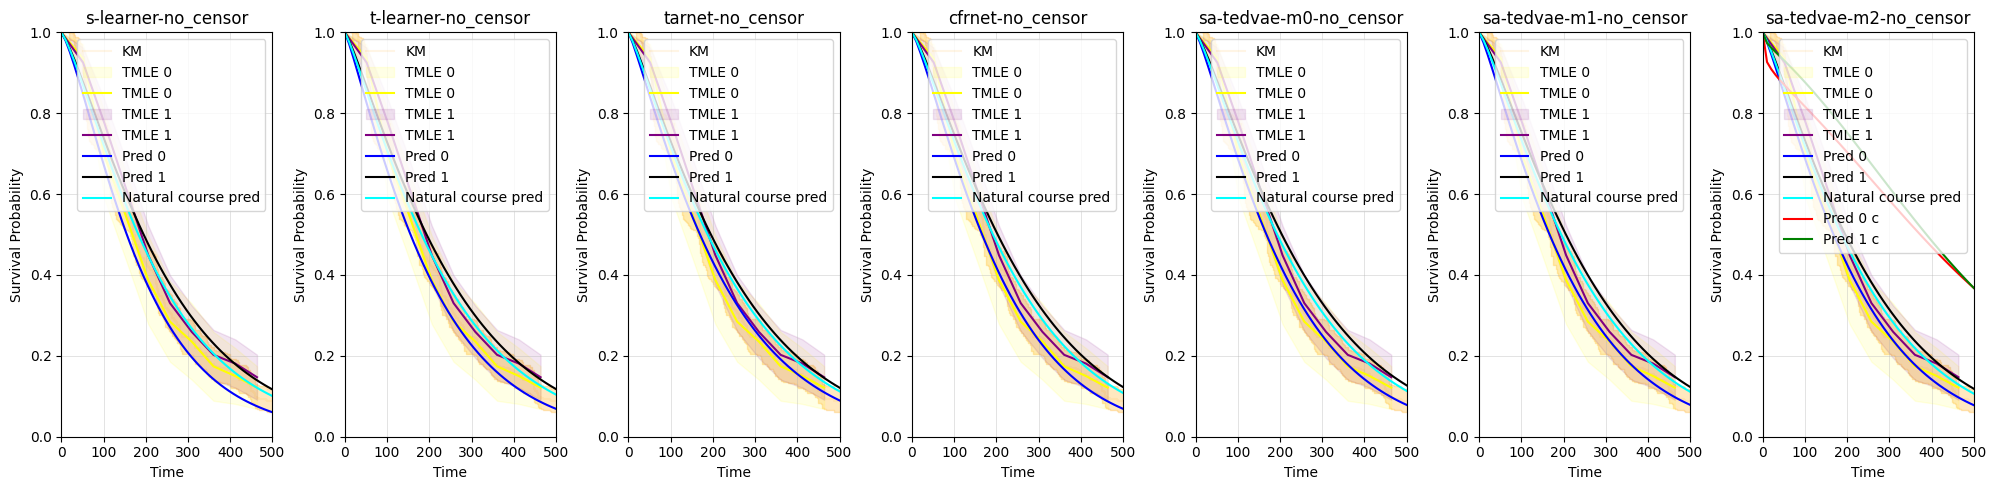

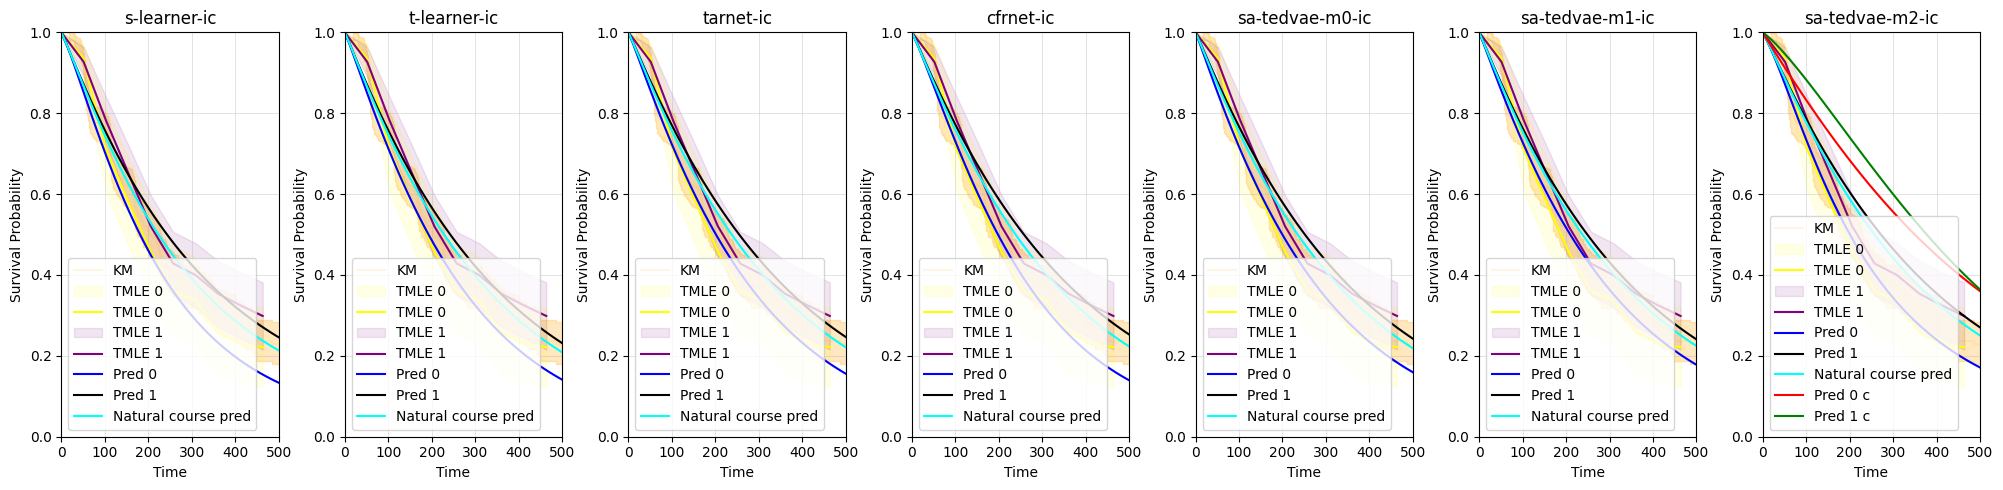

In [18]:
# Plot the aggregate predictions over all patients compared to the natural course FOR A SINGLE DATASET, WITH TMLE
max_t = 500
time_vector = np.linspace(0, max_t, 50)  # Vector to plot the time
models_to_show = ['s-learner', 't-learner', 'tarnet', 'cfrnet', 'sa-tedvae-m0', 'sa-tedvae-m1', 'sa-tedvae-m2']
i = 0  # Dataset index to plot, change this to plot different datasets

def aux_plot(arrays, label, color, percentile=2.5, additional_arrays=None, t=None):
    arrays = np.array(arrays).squeeze()
    if additional_arrays is not None:
        additional_arrays = np.array(additional_arrays).squeeze()
        new_arrays = np.zeros_like(arrays)
        for i in range(arrays.shape[0]):
            new_arrays[i, :] = additional_arrays[i, :] * t[i] + arrays[i, :] * (1 - t[i])  # Assumes additional list of arrays is t=1
        arrays = new_arrays
    mean_val, std_val = np.mean(arrays, axis=0), np.std(arrays, axis=0)
    low_val, high_val = np.percentile(arrays, percentile, axis=0), np.percentile(arrays, 100 - percentile, axis=0)
    #plt.fill_between(time_vector, low_val, high_val, color=color, alpha=0.1) # To prevent cluttering the plot, we can remove the confidence intervals in this case
    plt.plot(time_vector, mean_val, label=label, color=color)


for setting in settings:

    plt.subplots(1, len(models_to_show), figsize=(20, 5))
    model_index_plot = 1

    for model_name in models_to_show:

        plt.subplot(1, len(models_to_show), model_index_plot)

        cr_data = load_data(i=i, setting=setting)  # Use all the data for KM.
        all_y = np.concatenate([cr_data['y_train'], cr_data['y_test']])
        all_c = np.concatenate([cr_data['c_train'], cr_data['c_test']])

        kmf = KaplanMeierFitter()
        kmf.fit(all_y, event_observed=1 - all_c)
        kmf.plot_survival_function(label='KM', color='orange', alpha=0.1)

        # Add TMLE
        tmle_est = results[setting][models[0]]['pred_tmle'][i]  # Note that we store TMLE in the first model
        time0 = tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["Time"].values
        mean0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["Pt Est"].values
        ci_lower0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["CI_lower"].values
        ci_upper0 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 0)]["CI_upper"].values
        time1 = tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["Time"].values
        mean1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["Pt Est"].values
        ci_lower1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["CI_lower"].values
        ci_upper1 = 1 - tmle_est[(tmle_est["Event"] == 1) & (tmle_est["Group"] == 1)]["CI_upper"].values

        plt.fill_between(time0, ci_lower0, ci_upper0, alpha=0.1, label='TMLE 0', color='yellow')
        plt.plot(time0, mean0, label='TMLE 0', color='yellow')
        plt.fill_between(time1, ci_lower1, ci_upper1, alpha=0.1, label='TMLE 1', color='purple')
        plt.plot(time1, mean1, label='TMLE 1', color='purple')

        curves = {'survival_test_0_censor_pred': [], 'survival_test_1_censor_pred': [],
                  'survival_test_0_outcome_pred': [],
                  'survival_test_1_outcome_pred': []}

        data_dict = {'outcome_scale_train': [o for o in results[setting][model_name]['outcome_scale_train'][i]],
                     'outcome_scale_test': [o for o in results[setting][model_name]['outcome_scale_test'][i]],
                     'outcome_concentration_train': [o for o in results[setting][model_name]['outcome_concentration_train'][i]],
                     'outcome_concentration_test': [o for o in results[setting][model_name]['outcome_concentration_test'][i]]}
        if model_name == 'sa-tedvae-m2':
            data_dict['censor_scale_train'] = [o for o in results[setting][model_name]['censor_scale_train'][i]]
            data_dict['censor_scale_test'] = [o for o in results[setting][model_name]['censor_scale_test'][i]]
            data_dict['censor_concentration_train'] = [o for o in results[setting][model_name]['censor_concentration_train'][i]]
            data_dict['censor_concentration_test'] = [o for o in results[setting][model_name]['censor_concentration_test'][i]]
        survival_train_0_censor_pred, survival_test_0_censor_pred, survival_train_1_censor_pred, survival_test_1_censor_pred, survival_train_0_outcome_pred, survival_test_0_outcome_pred, survival_train_1_outcome_pred, survival_test_1_outcome_pred = get_pred_curves(data_dict, time_vector)

        curves['survival_test_0_outcome_pred'].append(survival_test_0_outcome_pred.T)
        curves['survival_test_1_outcome_pred'].append(survival_test_1_outcome_pred.T)
        if model_name == 'sa-tedvae-m2':
            curves['survival_test_0_censor_pred'].append(survival_test_0_censor_pred.T)
            curves['survival_test_1_censor_pred'].append(survival_test_1_censor_pred.T)

        aux_plot(curves['survival_test_0_outcome_pred'], label=f"Pred 0", color='blue')
        aux_plot(curves['survival_test_1_outcome_pred'], label=f"Pred 1", color='black')
        # Add the natural course
        aux_plot(curves['survival_test_0_outcome_pred'], label=f"Natural course pred", color='cyan', additional_arrays=curves['survival_test_1_outcome_pred'], t=cr_data['t_test'])
        if model_name == 'sa-tedvae-m2':
            aux_plot(curves['survival_test_0_censor_pred'], label=f"Pred 0 c", color='red')
            aux_plot(curves['survival_test_1_censor_pred'], label=f"Pred 1 c", color='green')

        plt.title(f"{model_name}-{setting}")
        plt.xlabel("Time")
        plt.ylabel("Survival Probability")
        plt.ylim([0, 1])
        plt.xlim([0, max_t])
        plt.grid(True)
        plt.legend(loc='best')
        model_index_plot += 1
    plt.tight_layout()
    plt.show()


Using model M2 for censoring, which predicts time to censoring with a Weibull distribution
Model sa-tedvae-m2 is already trained, skipping training...


C:\Users\Alex\AppData\Local\Temp\ipykernel_12360\1213497637.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


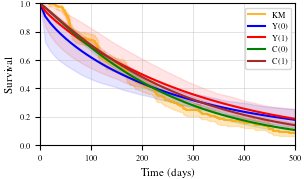

Patient features:
AGE: 1.1015609993265734
SEX: 0.0
RACCAT: 1.0
PRBEV: 0.0
PROXAL: 1.0
B_METACT: 2.0
B_LDHNM: -0.03919860568955052
BECOGICD: 1.0
DIAGTYPE: 0.0
PRADJYN: 0.0
LIVERMET: 1.0
KRAS: 3.0


In [19]:
# Show an individual prediction with confidence intervals
max_t = 500
time_vector = np.linspace(0, max_t, 50)  # Vector to plot the time
i = 0  # Dataset index to plot, change this to plot different datasets
pat_index = 0  # Patient index to plot, change this to plot different patients
setting = 'no_censor'
n_latent_samples = 100

from models.potential_outcomes import TEDVAE

cr_data = load_data(i=i, setting=setting)

def aux_plot(arrays, label, color, idx=None, percentile=5, additional_arrays=None, t=None):
    arrays = np.array(arrays).squeeze()
    if additional_arrays is not None:
        additional_arrays = np.array(additional_arrays).squeeze()
        new_arrays = np.zeros_like(arrays)
        for i in range(arrays.shape[0]):
            new_arrays[i, :] = additional_arrays[i, :] * t[i] + arrays[i, :] * (1 - t[i])  # Assumes additional list of arrays is t=1
        arrays = new_arrays
    if idx is not None:
        arrays = arrays[idx, :]  # Select only the patients by strata
    mean_val, std_val = np.mean(arrays, axis=0), np.std(arrays, axis=0)
    low_val, high_val = np.percentile(arrays, percentile, axis=0), np.percentile(arrays, 100 - percentile, axis=0)
    plt.fill_between(time_vector, low_val, high_val, color=color, alpha=0.1)
    plt.plot(time_vector, mean_val, label=label, color=color)

with plt.rc_context({**bundles.icml2024(column='half', nrows=1, ncols=1, usetex=True)}):

    plt.figure()

    # Poplation-level curve
    all_y = np.concatenate([cr_data['y_train'], cr_data['y_test']])
    all_c = np.concatenate([cr_data['c_train'], cr_data['c_test']])
    kmf = KaplanMeierFitter()
    kmf.fit(all_y, event_observed=1 - all_c)
    kmf.plot_survival_function(label='KM', color='orange', alpha=0.8)

    # Add SA-TEDVAE-M2 predictions
    hyperparameters = load_hyperparameters('sa-tedvae-m2', setting, best=True, path=os.path.join(save_path, 'hyperparameters'))
    # Load a trained model
    model = train_and_validate_model('sa-tedvae-m2', TEDVAE, setting, i, hyperparameters, model_path=os.path.join(save_path, 'models'), save_model=False, train_anyway=False, WANDB_MODE='disabled', disable_tqdm=True)
    model.seed_everything(0)  # Set seed for reproducibility
    preds = [model.predict(cr_data['X_test'], load_model='best') for _ in range(n_latent_samples)]
    outcome_scale_0 = [p['y_dist_list'][0].scale.detach().cpu().numpy() for p in preds]
    outcome_concentration_0 = [p['y_dist_list'][0].concentration.detach().cpu().numpy() for p in preds]
    outcome_scale_1 = [p['y_dist_list'][1].scale.detach().cpu().numpy() for p in preds]
    outcome_concentration_1 = [p['y_dist_list'][1].concentration.detach().cpu().numpy() for p in preds]
    censor_scale_0 = [p['c_dist_list'][0].scale.detach().cpu().numpy() for p in preds]
    censor_concentration_0 = [p['c_dist_list'][0].concentration.detach().cpu().numpy() for p in preds]
    censor_scale_1 = [p['c_dist_list'][1].scale.detach().cpu().numpy() for p in preds]
    censor_concentration_1 = [p['c_dist_list'][1].concentration.detach().cpu().numpy() for p in preds]

    survival_0_outcome = get_weibull_survival(concentration=np.array([o[pat_index] for o in outcome_concentration_0]), scale=np.array([o[pat_index] for o in outcome_scale_0]), time_vector=time_vector).T
    survival_1_outcome = get_weibull_survival(concentration=np.array([o[pat_index] for o in outcome_concentration_1]), scale=np.array([o[pat_index] for o in outcome_scale_1]), time_vector=time_vector).T
    survival_0_censor = get_weibull_survival(concentration=np.array([o[pat_index] for o in censor_concentration_0]), scale=np.array([o[pat_index] for o in censor_scale_0]), time_vector=time_vector).T
    survival_1_censor = get_weibull_survival(concentration=np.array([o[pat_index] for o in censor_concentration_1]), scale=np.array([o[pat_index] for o in censor_scale_1]), time_vector=time_vector).T

    aux_plot(survival_0_outcome, label=f"Y(0)", color='blue')
    aux_plot(survival_1_outcome, label=f"Y(1)", color='red')
    aux_plot(survival_0_censor, label=f"C(0)", color='green')
    aux_plot(survival_1_censor, label=f"C(1)", color='brown')

    #plt.title(f"SA-TEDVAE-M2-{setting}")
    plt.xlabel("Time (days)")
    plt.ylabel("Survival")
    plt.ylim([0, 1])
    plt.xlim([0, max_t])
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.rcParams.update(bundles.icml2024(usetex=False))
    plt.savefig(os.path.join(plots_path, f'crc_patient.pdf'), dpi=300)
    plt.show()

# Print the patient features for the two patients
print("Patient features:")
for feature_name, value in zip(cr_data['x_columns'], cr_data['X_test'][pat_index]):
    print(f"{feature_name}: {value}")
